# 05. Advanced Motion & Target Displacement Analysis
This notebook implements the advanced EDA strategies identified to refine the predictive model: Maneuverability profiles, Target displacement distributions, and Vertical dynamics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.auto import tqdm

DATA_DIR = '../data/open/train/'
LABEL_PATH = '../data/open/train_labels.csv'
DT = 0.040
sns.set_theme(style='whitegrid')

c:\Repo\dacon-mosquito-trajectory\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Feature Prep
Loading a sample and calculating kinematics.

In [5]:
def add_kinematics(df):
    df = df.copy()
    for col in ['x', 'y', 'z']: df[col] = df[col].astype(float)
    df[['vx', 'vy', 'vz']] = df.groupby('id')[['x', 'y', 'z']].diff() / DT
    v_vals = df[['vx', 'vy', 'vz']].values.astype(float)
    df['speed'] = np.linalg.norm(v_vals, axis=1)
    
    df[['ax', 'ay', 'az']] = df.groupby('id')[['vx', 'vy', 'vz']].diff() / DT
    a_vals = df[['ax', 'ay', 'az']].values.astype(float)
    
    # Curvature calculation
    cross = np.cross(v_vals, a_vals)
    cross_mag = np.linalg.norm(cross, axis=1)
    df['curvature'] = cross_mag / (df['speed']**3 + 1e-6)
    return df

train_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))
all_data = []
for f in tqdm(train_files[:2000]):
    df = pd.read_csv(f)
    df['id'] = os.path.basename(f).split('.')[0]
    all_data.append(df)

df_full = pd.concat(all_data, ignore_index=True)
df_kin = add_kinematics(df_full).dropna()

100%|██████████| 2000/2000 [00:01<00:00, 1250.34it/s]


## 2. Maneuverability Profile: Speed vs. Curvature
Does the mosquito slow down to make sharp turns?

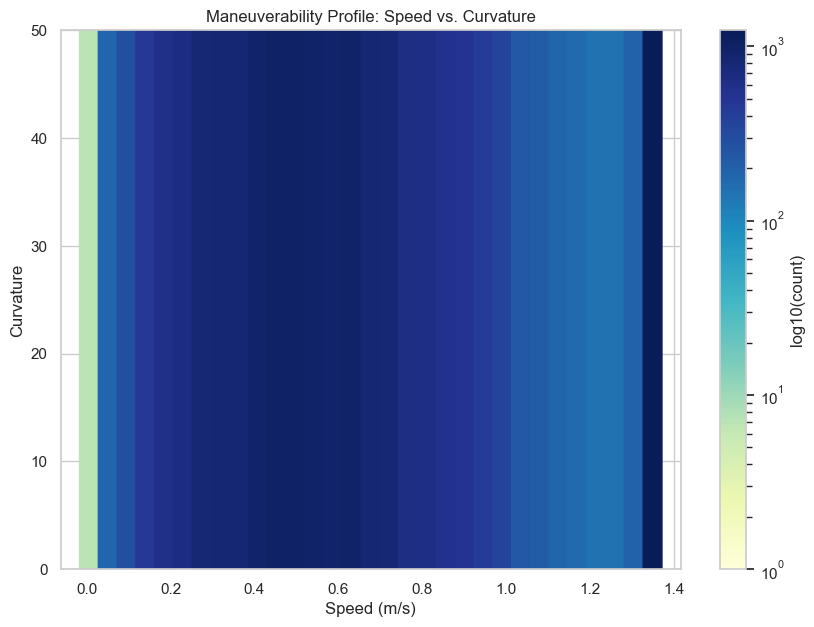

In [6]:
plt.figure(figsize=(10, 7))
plt.hexbin(df_kin['speed'], df_kin['curvature'], gridsize=30, cmap='YlGnBu', bins='log')
plt.colorbar(label='log10(count)')
plt.xlabel('Speed (m/s)')
plt.ylabel('Curvature')
plt.ylim(0, 50)  # Clipping high curvature for visibility
plt.title('Maneuverability Profile: Speed vs. Curvature')
plt.show()

## 3. Target Displacement Distribution
Analyzing the labels relative to the last known position ($t=0$).

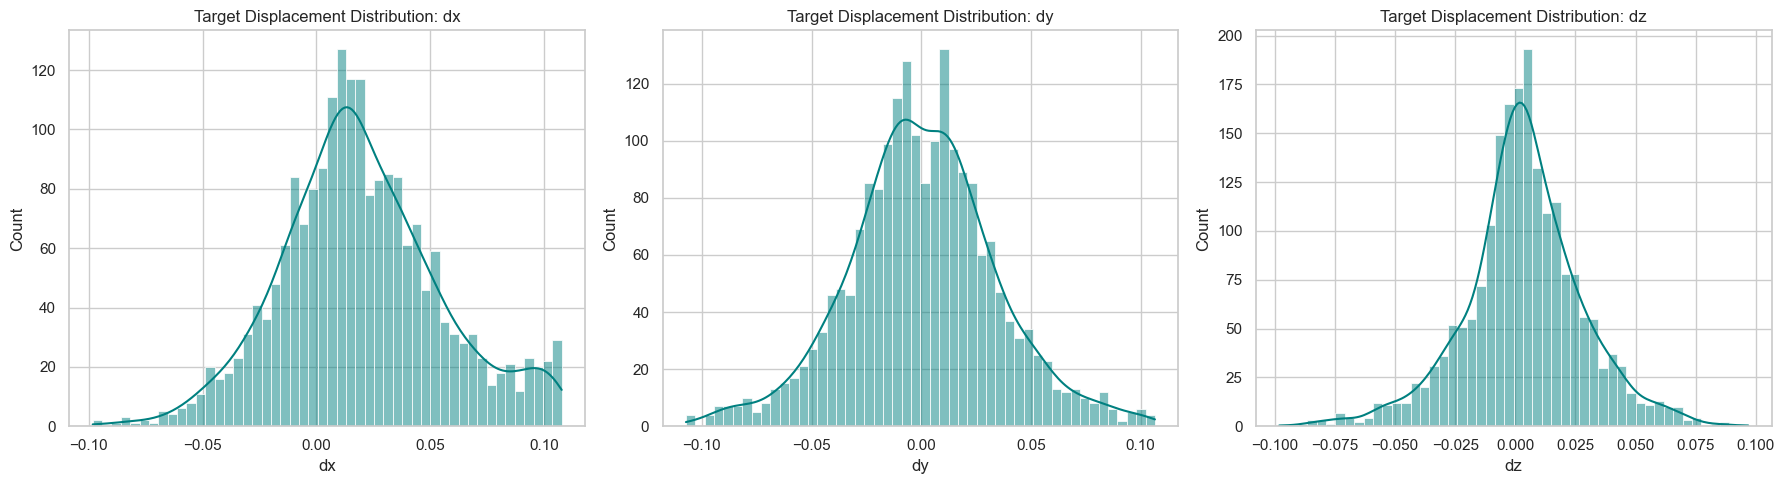

Displacement Statistics:
                dx           dy           dz
count  2000.000000  2000.000000  2000.000000
mean      0.019772     0.000495     0.003274
std       0.035545     0.033989     0.024618
min      -0.098317    -0.107218    -0.098132
25%      -0.002845    -0.020281    -0.009030
50%       0.016622    -0.000313     0.003178
75%       0.040661     0.020956     0.016706
max       0.107827     0.106476     0.096797


In [8]:
labels = pd.read_csv(LABEL_PATH)
last_points = df_full.groupby('id').tail(1)[['id', 'x', 'y', 'z']].rename(columns={'x':'x0', 'y':'y0', 'z':'z0'})
merged = pd.merge(labels, last_points, on='id')

merged['dx'] = merged['x'] - merged['x0']
merged['dy'] = merged['y'] - merged['y0']
merged['dz'] = merged['z'] - merged['z0']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['dx', 'dy', 'dz']):
    sns.histplot(merged[col], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Target Displacement Distribution: {col}')
plt.tight_layout()
plt.show()

print("Displacement Statistics:")
print(merged[['dx', 'dy', 'dz']].describe())

## 4. Vertical Stratification
Do kinematics change with height?

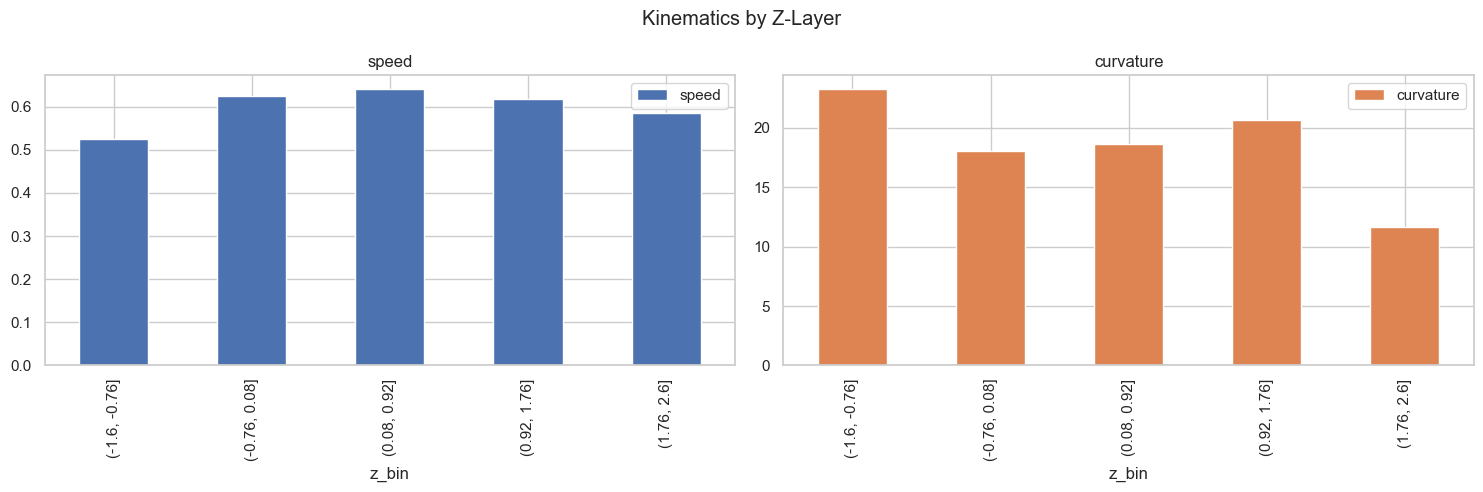

In [9]:
df_kin['z_bin'] = pd.cut(df_kin['z'], bins=np.linspace(-1.6, 2.6, 6))
stratified_stats = df_kin.groupby('z_bin', observed=False)[['speed', 'curvature']].mean()

stratified_stats.plot(kind='bar', subplots=True, layout=(1, 2), figsize=(15, 5), title='Kinematics by Z-Layer')
plt.tight_layout()
plt.show()

## Summary of Findings
1. **Maneuverability**: High curvature is strictly concentrated at lower speeds, confirming that sharp turns require deceleration.
2. **Target Bias**: Check the mean of `dx, dy, dz` to see if there is a prevailing "wind" or drift in the arena.
3. **Z-Dynamics**: Identify which layers have the most erratic movement (highest mean curvature).